# Problem 4 — viation Accident Data Analysis



## 1. Setup and Imports

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import statsmodels.api as sm
import patsy

warnings.filterwarnings("ignore")
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()
DATA_CANDIDATES = [
    BASE_DIR / "aviation_accident.csv",
    Path("/aviation_accident.csv"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find aviation_accident.csv."
    )

OUT_DIR = BASE_DIR / "problem4_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print(f"Using data file: {DATA_PATH}")
print(f"Outputs will be saved to: {OUT_DIR}")

Using data file: /content/aviation_accident.csv
Outputs will be saved to: /content/problem4_outputs


## 2. Helper Functions

In [2]:
def standardize_text_series(series: pd.Series, missing_label: str = "Unknown/Missing") -> pd.Series:
    """Clean categorical text values and combine several unknown-like labels."""
    cleaned = (
        series.astype("object")
        .where(~series.isna(), missing_label)
        .astype(str)
        .str.strip()
    )
    cleaned = cleaned.replace({
        "": missing_label,
        "nan": missing_label,
        "NaN": missing_label,
        "Unknown": missing_label,
        "UNK": missing_label,
        "NONE": missing_label,
        "None": missing_label,
    })
    return cleaned


def collapse_rare(series: pd.Series, min_count: int = 200, other_label: str = "Other/Rare") -> pd.Series:
    """Collapse low-frequency categories to keep models interpretable and stable."""
    counts = series.value_counts(dropna=False)
    keep = set(counts[counts >= min_count].index)
    return series.where(series.isin(keep), other_label)


def save_barh(df: pd.DataFrame, y_col: str, x_col: str, title: str, xlabel: str, path: Path):
    """Save a simple horizontal bar chart using matplotlib."""
    plt.figure(figsize=(8, 5))
    plt.barh(df[y_col], df[x_col])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()
    plt.close()


def term_label(term: str) -> str:
    """Make statsmodels term names easier to read in the output table."""
    replacements = {
        'C(weather, Treatment(reference="VMC"))[T.': 'Weather: ',
        'C(phase, Treatment(reference="Landing"))[T.': 'Phase: ',
        'C(amateur, Treatment(reference="No"))[T.': 'Amateur-built: ',
        'C(purpose, Treatment(reference="Personal"))[T.': 'Purpose: ',
        'C(engine, Treatment(reference="Reciprocating"))[T.': 'Engine: ',
    }
    label = term
    for old, new in replacements.items():
        label = label.replace(old, new)
    label = label.replace(']', '')
    label = label.replace('Intercept', 'Intercept')
    label = label.replace('year_clean', 'Event year')
    label = label.replace('engines_num', 'Number of engines')
    return label

## 3. Load Data

In [3]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw dataset shape: {df_raw.shape}")
df_raw.head()

Raw dataset shape: (68565, 31)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Year,Month.Abbr,Day.Name.Abbr,Weekend,City,State
0,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,BLACKBURN AG STRIP,Non-Fatal,Substantial,...,VMC,Takeoff,Probable Cause,01-01-1982,1982.0,Jan,Fri,False,PULLMAN,WA
1,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,N58,HANOVER,Non-Fatal,Substantial,...,IMC,Landing,Probable Cause,01-01-1982,1982.0,Jan,Fri,False,EAST HANOVER,NJ
2,20020909X01560,Accident,MIA82DA029,1982-01-01,"JACKSONVILLE, FL",United States,JAX,JACKSONVILLE INTL,Non-Fatal,Substantial,...,IMC,Cruise,Probable Cause,01-01-1982,1982.0,Jan,Fri,False,JACKSONVILLE,FL
3,20020909X01559,Accident,FTW82DA034,1982-01-01,"HOBBS, NM",United States,NaN,NaN,Non-Fatal,Substantial,...,VMC,Approach,Probable Cause,01-01-1982,1982.0,Jan,Fri,False,HOBBS,NM
4,20020909X01558,Accident,ATL82DKJ10,1982-01-01,"TUSKEGEE, AL",United States,NaN,TUSKEGEE,Non-Fatal,Substantial,...,VMC,Landing,Probable Cause,01-01-1982,1982.0,Jan,Fri,False,TUSKEGEE,AL


## 4. Data Cleaning and Feature Engineering



In [4]:
df = df_raw.copy()

# Date cleaning
if "Event.Date" not in df.columns:
    raise KeyError("Expected column 'Event.Date' was not found in aviation_accident.csv.")

df["event_date_clean"] = pd.to_datetime(df["Event.Date"], errors="coerce")
df["year_clean"] = df["event_date_clean"].dt.year

#
valid_year_mask = df["year_clean"].between(1982, 2022, inclusive="both")
df = df.loc[valid_year_mask].copy()

# Numeric conversion
injury_cols = [
    "Total.Fatal.Injuries",
    "Total.Serious.Injuries",
    "Total.Minor.Injuries",
    "Total.Uninjured",
]

for col in injury_cols + ["Number.of.Engines"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        raise KeyError(f"Expected column '{col}' was not found.")

for col in injury_cols:
    df[col] = df[col].fillna(0)

# Clean categorical variables
categorical_source_cols = [
    "Aircraft.damage",
    "Weather.Condition",
    "Broad.phase.of.flight",
    "Purpose.of.flight",
    "Engine.Type",
]

for col in categorical_source_cols:
    if col not in df.columns:
        raise KeyError(f"Expected column '{col}' was not found.")
    df[f"{col}.clean"] = standardize_text_series(df[col])

#
df["Amateur.Built.clean"] = df["Amateur.Built"].map({
    True: "Yes",
    False: "No",
    "True": "Yes",
    "False": "No",
})
df["Amateur.Built.clean"] = df["Amateur.Built.clean"].fillna("Unknown/Missing")

#
df["total_people"] = df[injury_cols].sum(axis=1)
df["survival_rate"] = np.where(
    df["total_people"] > 0,
    (
        df["Total.Serious.Injuries"]
        + df["Total.Minor.Injuries"]
        + df["Total.Uninjured"]
    ) / df["total_people"],
    np.nan,
)

df["fatal_accident"] = (df["Total.Fatal.Injuries"] > 0).astype(int)
df["severe_accident"] = (
    (df["Total.Fatal.Injuries"] > 0)
    | (df["Aircraft.damage.clean"].str.lower() == "destroyed")
).astype(int)

print(f"Records after 1982-2022 year cleaning: {len(df):,}")
print(f"Overall average survival rate: {df['survival_rate'].mean() * 100:.1f}%")
print(f"Fatal accident share: {df['fatal_accident'].mean() * 100:.1f}%")
print(f"Severe accident share: {df['severe_accident'].mean() * 100:.1f}%")
df[["year_clean", "survival_rate", "fatal_accident", "severe_accident"]].head()

Records after 1982-2022 year cleaning: 67,128
Overall average survival rate: 83.0%
Fatal accident share: 18.6%
Severe accident share: 26.1%


,year_clean,survival_rate,fatal_accident,severe_accident
0,1982.0,1.0,0,0
1,1982.0,1.0,0,0
2,1982.0,1.0,0,0
3,1982.0,1.0,0,0
4,1982.0,1.0,0,0


## 5. Missingness Summary



In [5]:
key_cols_for_missingness = [
    "Event.Date",
    "Weather.Condition",
    "Broad.phase.of.flight",
    "Aircraft.damage",
    "Purpose.of.flight",
    "Engine.Type",
    "Number.of.Engines",
    "Amateur.Built",
    "Total.Fatal.Injuries",
    "Total.Serious.Injuries",
    "Total.Minor.Injuries",
    "Total.Uninjured",
]

missing_summary = (
    df_raw[key_cols_for_missingness]
    .isna()
    .mean()
    .reset_index()
    .rename(columns={"index": "variable", 0: "missing_rate"})
)
missing_summary["missing_percent"] = 100 * missing_summary["missing_rate"]
missing_summary = missing_summary.sort_values("missing_percent", ascending=False)
missing_summary.to_csv(OUT_DIR / "missingness_summary.csv", index=False)
missing_summary

,variable,missing_rate,missing_percent
2,Broad.phase.of.flight,0.321301,32.130096
5,Engine.Type,0.058339,5.833880
6,Number.of.Engines,0.044688,4.468752
4,Purpose.of.flight,0.037278,3.727849
3,Aircraft.damage,0.034362,3.436155
1,Weather.Condition,0.028644,2.864435
7,Amateur.Built,0.020973,2.097280
8,Total.Fatal.Injuries,0.020958,2.095821
10,Total.Minor.Injuries,0.020958,2.095821
9,Total.Serious.Injuries,0.020958,2.095821


## 6. Descriptive Analysis Tables

In [6]:
dataset_summary = pd.DataFrame({
    "metric": [
        "Raw records",
        "Usable records after 1982-2022 date cleaning",
        "Year range",
        "Records with reported occupants for survival rate",
        "Overall average survival rate",
        "Fatal accident share",
        "Severe accident share",
    ],
    "value": [
        f"{len(df_raw):,}",
        f"{len(df):,}",
        f"{int(df['year_clean'].min())}-{int(df['year_clean'].max())}",
        f"{df['survival_rate'].notna().sum():,}",
        f"{df['survival_rate'].mean() * 100:.1f}%",
        f"{df['fatal_accident'].mean() * 100:.1f}%",
        f"{df['severe_accident'].mean() * 100:.1f}%",
    ]
})

accidents_by_year = (
    df.groupby("year_clean")
    .size()
    .reset_index(name="accident_count")
    .sort_values("year_clean")
)

survival_by_year = (
    df.groupby("year_clean")
    .agg(
        avg_survival_rate=("survival_rate", "mean"),
        records_with_survival_rate=("survival_rate", "count"),
    )
    .reset_index()
)
survival_by_year["avg_survival_percent"] = 100 * survival_by_year["avg_survival_rate"]

phase_summary = (
    df.groupby("Broad.phase.of.flight.clean")
    .agg(
        accidents=("Event.Id", "count"),
        severe_rate=("severe_accident", "mean"),
        fatal_rate=("fatal_accident", "mean"),
        avg_survival_rate=("survival_rate", "mean"),
    )
    .reset_index()
    .rename(columns={"Broad.phase.of.flight.clean": "phase_of_flight"})
)
phase_summary["severe_percent"] = 100 * phase_summary["severe_rate"]
phase_summary["fatal_percent"] = 100 * phase_summary["fatal_rate"]
phase_summary["avg_survival_percent"] = 100 * phase_summary["avg_survival_rate"]
phase_summary = phase_summary.sort_values("accidents", ascending=False)

weather_summary = (
    df.groupby("Weather.Condition.clean")
    .agg(
        accidents=("Event.Id", "count"),
        severe_rate=("severe_accident", "mean"),
        fatal_rate=("fatal_accident", "mean"),
        avg_survival_rate=("survival_rate", "mean"),
    )
    .reset_index()
    .rename(columns={"Weather.Condition.clean": "weather_condition"})
)
weather_summary["severe_percent"] = 100 * weather_summary["severe_rate"]
weather_summary["fatal_percent"] = 100 * weather_summary["fatal_rate"]
weather_summary["avg_survival_percent"] = 100 * weather_summary["avg_survival_rate"]
weather_summary = weather_summary.sort_values("severe_percent", ascending=False)

#
phase_weather_summary = (
    df.groupby(["Broad.phase.of.flight.clean", "Weather.Condition.clean"])
    .agg(
        accidents=("Event.Id", "count"),
        severe_rate=("severe_accident", "mean"),
        fatal_rate=("fatal_accident", "mean"),
    )
    .reset_index()
    .rename(columns={
        "Broad.phase.of.flight.clean": "phase_of_flight",
        "Weather.Condition.clean": "weather_condition",
    })
)
phase_weather_summary["severe_percent"] = 100 * phase_weather_summary["severe_rate"]
phase_weather_summary["fatal_percent"] = 100 * phase_weather_summary["fatal_rate"]
phase_weather_summary = phase_weather_summary.sort_values(
    ["phase_of_flight", "severe_percent"], ascending=[True, False]
)

#
with pd.ExcelWriter(OUT_DIR / "part4_analysis_tables.xlsx", engine="openpyxl") as writer:
    dataset_summary.to_excel(writer, sheet_name="dataset_summary", index=False)
    missing_summary.to_excel(writer, sheet_name="missing_summary", index=False)
    accidents_by_year.to_excel(writer, sheet_name="accidents_by_year", index=False)
    survival_by_year.to_excel(writer, sheet_name="survival_by_year", index=False)
    phase_summary.to_excel(writer, sheet_name="phase_summary", index=False)
    weather_summary.to_excel(writer, sheet_name="weather_summary", index=False)
    phase_weather_summary.to_excel(writer, sheet_name="phase_weather", index=False)

print(f"Saved descriptive tables to {OUT_DIR / 'part4_analysis_tables.xlsx'}")
dataset_summary

Saved descriptive tables to /content/problem4_outputs/part4_analysis_tables.xlsx


,metric,value
0,Raw records,"68,565"
1,Usable records after 1982-2022 date cleaning,"67,128"
2,Year range,1982-2022
3,Records with reported occupants for survival rate,"67,058"
4,Overall average survival rate,83.0%
5,Fatal accident share,18.6%
6,Severe accident share,26.1%


## 7. Descriptive Figures


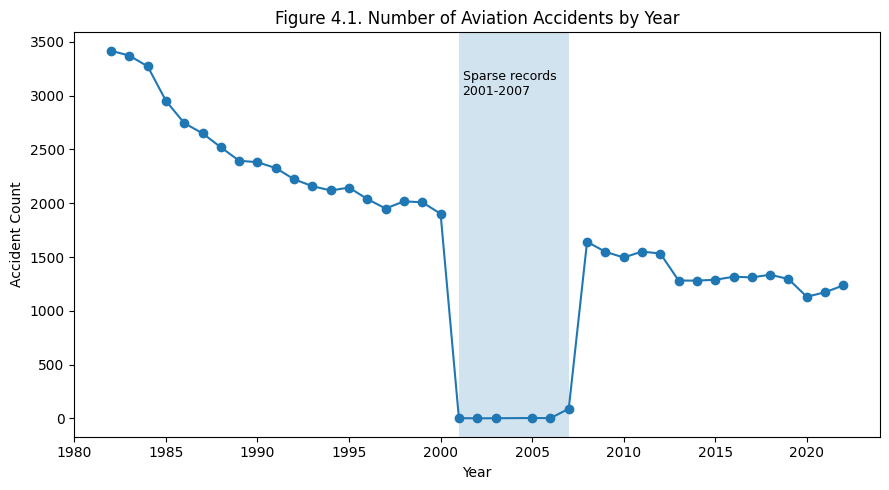

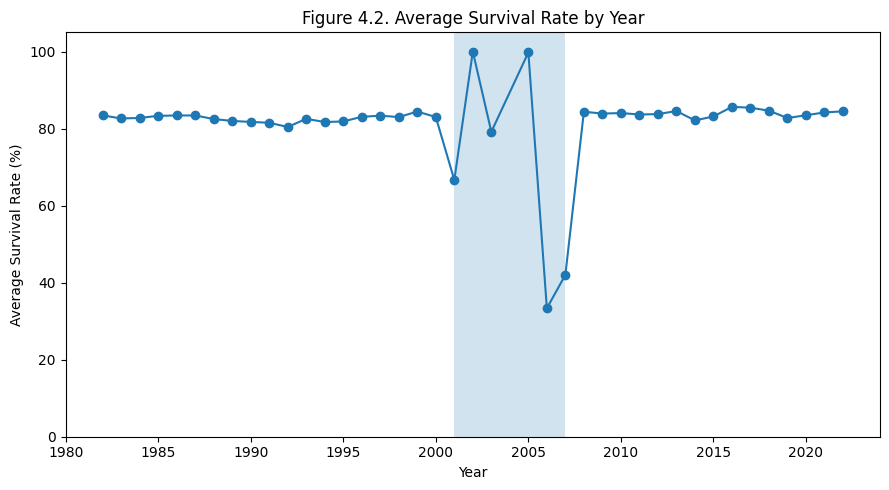

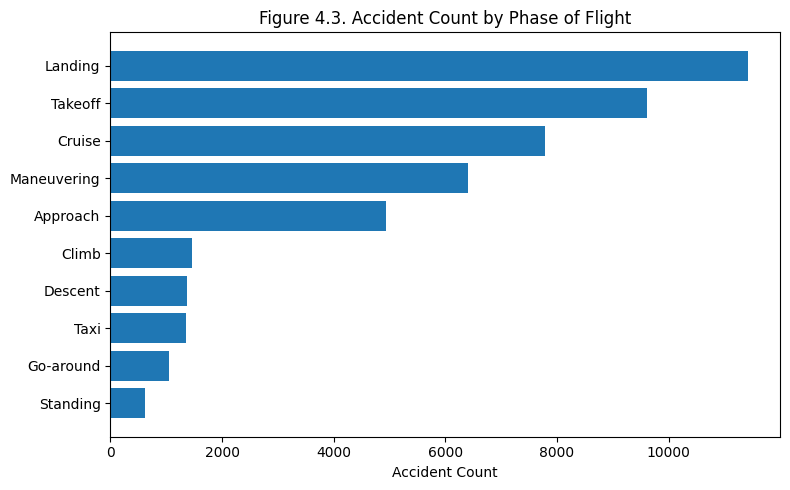

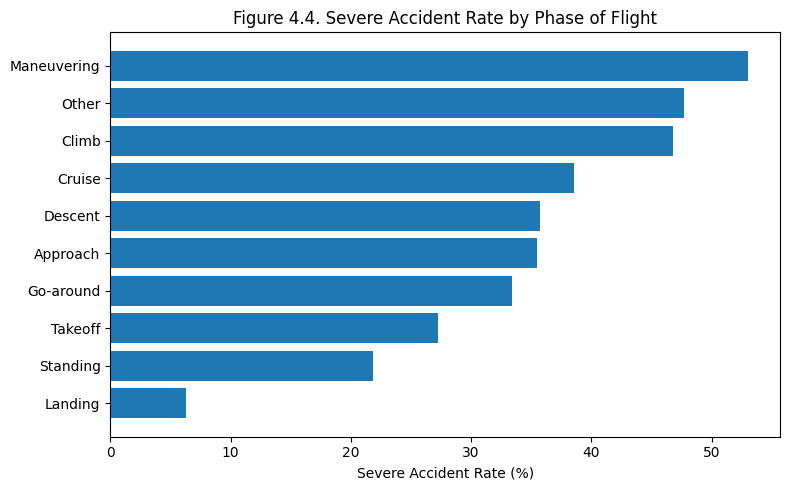

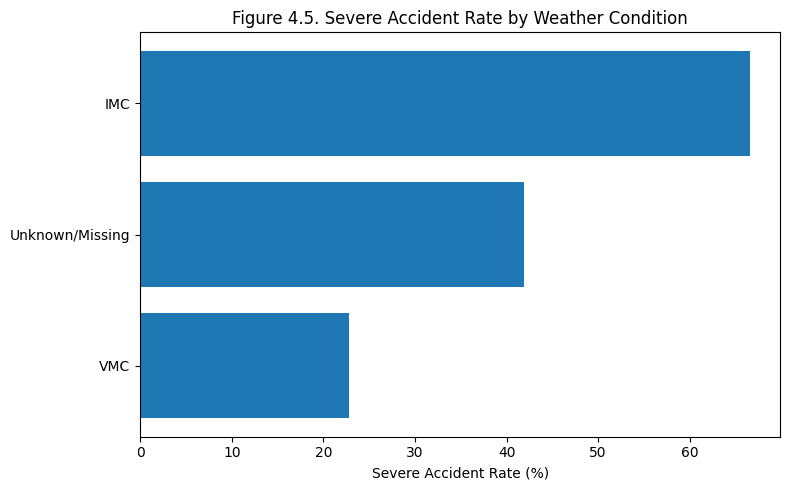

In [7]:
# Figure 4.1: Accident count by year, with sparse-data period marked.
plt.figure(figsize=(9, 5))
plt.plot(accidents_by_year["year_clean"], accidents_by_year["accident_count"], marker="o", linewidth=1.5)
plt.axvspan(2001, 2007, alpha=0.2)
plt.text(
    2001.2,
    accidents_by_year["accident_count"].max() * 0.88,
    "Sparse records\n2001-2007",
    fontsize=9,
)
plt.title("Figure 4.1. Number of Aviation Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Accident Count")
plt.tight_layout()
plt.savefig(OUT_DIR / "figure4_1_accidents_by_year.png", dpi=200)
plt.show()
plt.close()

# Figure 4.2: Average survival rate by year.
plt.figure(figsize=(9, 5))
plt.plot(survival_by_year["year_clean"], survival_by_year["avg_survival_percent"], marker="o", linewidth=1.5)
plt.axvspan(2001, 2007, alpha=0.2)
plt.title("Figure 4.2. Average Survival Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average Survival Rate (%)")
plt.ylim(0, 105)
plt.tight_layout()
plt.savefig(OUT_DIR / "figure4_2_survival_rate_by_year.png", dpi=200)
plt.show()
plt.close()

# Figure 4.3: Accident count by phase.
phase_count_plot = phase_summary[phase_summary["phase_of_flight"] != "Unknown/Missing"].head(10)
save_barh(
    phase_count_plot,
    y_col="phase_of_flight",
    x_col="accidents",
    title="Figure 4.3. Accident Count by Phase of Flight",
    xlabel="Accident Count",
    path=OUT_DIR / "figure4_3_accidents_by_phase.png",
)

# Figure 4.4: Severe accident rate by phase.
phase_severity_plot = (
    phase_summary[phase_summary["phase_of_flight"] != "Unknown/Missing"]
    .sort_values("severe_percent", ascending=False)
    .head(10)
)
save_barh(
    phase_severity_plot,
    y_col="phase_of_flight",
    x_col="severe_percent",
    title="Figure 4.4. Severe Accident Rate by Phase of Flight",
    xlabel="Severe Accident Rate (%)",
    path=OUT_DIR / "figure4_4_severity_by_phase.png",
)

# Figure 4.5: Severe accident rate by weather condition.
weather_plot = weather_summary.copy()
save_barh(
    weather_plot,
    y_col="weather_condition",
    x_col="severe_percent",
    title="Figure 4.5. Severe Accident Rate by Weather Condition",
    xlabel="Severe Accident Rate (%)",
    path=OUT_DIR / "figure4_5_severity_by_weather.png",
)

## 8. Predictive Logistic Regression



In [8]:
df_model = df.copy()
df_model["Purpose.of.flight.model"] = collapse_rare(df_model["Purpose.of.flight.clean"], min_count=200)
df_model["Engine.Type.model"] = collapse_rare(df_model["Engine.Type.clean"], min_count=200)
df_model["Broad.phase.of.flight.model"] = collapse_rare(df_model["Broad.phase.of.flight.clean"], min_count=200)

numeric_features = ["year_clean", "Number.of.Engines"]
categorical_features = [
    "Weather.Condition.clean",
    "Broad.phase.of.flight.model",
    "Amateur.Built.clean",
    "Purpose.of.flight.model",
    "Engine.Type.model",
]

X = df_model[numeric_features + categorical_features].copy()
y = df_model["severe_accident"].astype(int)
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown/Missing")),
    ("onehot", one_hot_encoder),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

predictive_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE,
    )),
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

predictive_model.fit(X_train, y_train)
y_test_proba = predictive_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.50).astype(int)

test_auc = roc_auc_score(y_test, y_test_proba)
test_accuracy = accuracy_score(y_test, y_test_pred)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc_scores = cross_val_score(
    predictive_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,
)

regression_summary = pd.DataFrame({
    "metric": [
        "Number of observations",
        "Severe accident share",
        "Train size",
        "Test size",
        "Test AUC",
        "Test accuracy at 0.50 threshold",
        "5-fold CV AUC mean",
        "5-fold CV AUC std",
    ],
    "value": [
        len(df_model),
        y.mean(),
        len(X_train),
        len(X_test),
        test_auc,
        test_accuracy,
        cv_auc_scores.mean(),
        cv_auc_scores.std(),
    ]
})
regression_summary.to_csv(OUT_DIR / "regression_summary.csv", index=False)
regression_summary

,metric,value
0,Number of observations,67128.000000
1,Severe accident share,0.261217
2,Train size,50346.000000
3,Test size,16782.000000
4,Test AUC,0.754064
5,Test accuracy at 0.50 threshold,0.677035
6,5-fold CV AUC mean,0.753488
7,5-fold CV AUC std,0.004613


## 9. Confusion Matrix, Classification Report, and ROC Curve

Confusion matrix:


,Predicted non-severe,Predicted severe
Actual non-severe,8387,4011
Actual severe,1409,2975


Classification report:


,precision,recall,f1-score,support
0,0.856166,0.676480,0.755790,12398.000000
1,0.425852,0.678604,0.523307,4384.000000
accuracy,0.677035,0.677035,0.677035,0.677035
macro avg,0.641009,0.677542,0.639548,16782.000000
weighted avg,0.743754,0.677035,0.695058,16782.000000


<Figure size 600x500 with 0 Axes>

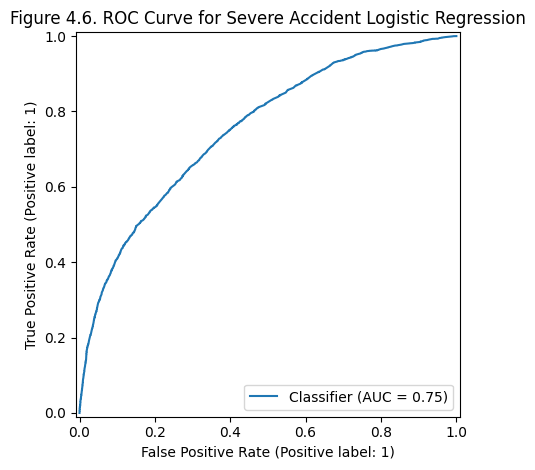

In [9]:
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual non-severe", "Actual severe"],
    columns=["Predicted non-severe", "Predicted severe"],
)
cm_df.to_csv(OUT_DIR / "confusion_matrix.csv")

classification_report_df = pd.DataFrame(
    classification_report(y_test, y_test_pred, output_dict=True)
).T
classification_report_df.to_csv(OUT_DIR / "classification_report.csv")

print("Confusion matrix:")
display(cm_df)
print("Classification report:")
display(classification_report_df)

plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_test_proba)
plt.title("Figure 4.6. ROC Curve for Severe Accident Logistic Regression")
plt.tight_layout()
plt.savefig(OUT_DIR / "figure4_6_roc_curve.png", dpi=200)
plt.show()
plt.close()

## 10. Interpretation-Oriented Logistic Regression



In [10]:
df_interpret = df.copy()
df_interpret["weather"] = df_interpret["Weather.Condition.clean"].where(
    df_interpret["Weather.Condition.clean"].isin(["VMC", "IMC", "Unknown/Missing"]),
    "Unknown/Missing",
)

phase_categories = [
    "Landing",
    "Takeoff",
    "Approach",
    "Cruise",
    "Maneuvering",
    "Climb",
    "Descent",
    "Taxi",
    "Go-around",
    "Standing",
    "Unknown/Missing",
]
df_interpret["phase"] = df_interpret["Broad.phase.of.flight.clean"].where(
    df_interpret["Broad.phase.of.flight.clean"].isin(phase_categories),
    "Other/Rare",
)

df_interpret["amateur"] = df_interpret["Amateur.Built.clean"].where(
    df_interpret["Amateur.Built.clean"].isin(["No", "Yes", "Unknown/Missing"]),
    "Unknown/Missing",
)

df_interpret["purpose"] = collapse_rare(df_interpret["Purpose.of.flight.clean"], min_count=500)
df_interpret["engine"] = collapse_rare(df_interpret["Engine.Type.clean"], min_count=500)
df_interpret["engines_num"] = df_interpret["Number.of.Engines"].fillna(
    df_interpret["Number.of.Engines"].median()
)

df_interpret["weather"] = pd.Categorical(
    df_interpret["weather"],
    categories=["VMC", "IMC", "Unknown/Missing"],
)
df_interpret["phase"] = pd.Categorical(
    df_interpret["phase"],
    categories=[
        "Landing",
        "Takeoff",
        "Approach",
        "Cruise",
        "Maneuvering",
        "Climb",
        "Descent",
        "Taxi",
        "Go-around",
        "Standing",
        "Unknown/Missing",
        "Other/Rare",
    ],
)
df_interpret["amateur"] = pd.Categorical(
    df_interpret["amateur"],
    categories=["No", "Yes", "Unknown/Missing"],
)

interpretation_formula = """
severe_accident ~ year_clean
+ engines_num
+ C(weather, Treatment(reference="VMC"))
+ C(phase, Treatment(reference="Landing"))
+ C(amateur, Treatment(reference="No"))
+ C(purpose, Treatment(reference="Personal"))
+ C(engine, Treatment(reference="Reciprocating"))
"""

y_glm, X_glm = patsy.dmatrices(
    interpretation_formula,
    data=df_interpret,
    return_type="dataframe",
)

glm_model = sm.GLM(y_glm, X_glm, family=sm.families.Binomial())
glm_result = glm_model.fit(maxiter=100)

params = glm_result.params
conf = glm_result.conf_int()
pvals = glm_result.pvalues

odds_ratio_table = pd.DataFrame({
    "term": params.index,
    "factor": [term_label(t) for t in params.index],
    "coef": params.values,
    "odds_ratio": np.exp(params.values),
    "ci_lower_95": np.exp(conf[0].values),
    "ci_upper_95": np.exp(conf[1].values),
    "p_value": pvals.values,
})

def reference_note(term: str) -> str:
    if "weather" in term:
        return "Reference: VMC"
    if "phase" in term:
        return "Reference: Landing"
    if "amateur" in term:
        return "Reference: Non-amateur-built / No"
    if "purpose" in term:
        return "Reference: Personal"
    if "engine" in term:
        return "Reference: Reciprocating"
    return ""

odds_ratio_table["reference"] = odds_ratio_table["term"].apply(reference_note)

odds_ratio_table.to_csv(OUT_DIR / "logit_interpretation_odds_ratios.csv", index=False)

key_terms_mask = odds_ratio_table["term"].str.contains("weather|phase|amateur", regex=True)
key_odds_ratios = odds_ratio_table.loc[key_terms_mask].sort_values("odds_ratio", ascending=False)
key_odds_ratios.to_csv(OUT_DIR / "key_interpretation_odds_ratios.csv", index=False)

print(f"GLM converged: {glm_result.converged}")
print(f"Saved interpretation odds ratios to {OUT_DIR / 'logit_interpretation_odds_ratios.csv'}")
key_odds_ratios[["factor", "reference", "odds_ratio", "ci_lower_95", "ci_upper_95", "p_value"]].head(15)

GLM converged: True
Saved interpretation odds ratios to /content/problem4_outputs/logit_interpretation_odds_ratios.csv


,factor,reference,odds_ratio,ci_lower_95,ci_upper_95,p_value
6,Phase: Maneuvering,Reference: Landing,1.941996e+01,17.646747,21.371361,0.000000e+00
13,Phase: Other/Rare,Reference: Landing,1.337506e+01,8.641327,20.701927,2.708524e-31
7,Phase: Climb,Reference: Landing,1.109103e+01,9.709032,12.669733,4.605356e-275
8,Phase: Descent,Reference: Landing,7.332007e+00,6.378405,8.428177,8.092521e-173
5,Phase: Cruise,Reference: Landing,7.197634e+00,6.567886,7.887764,0.000000e+00
12,Phase: Unknown/Missing,Reference: Landing,7.077506e+00,6.302556,7.947743,6.981916e-240
10,Phase: Go-around,Reference: Landing,6.887205e+00,5.888839,8.054829,7.433643e-129
4,Phase: Approach,Reference: Landing,6.390985e+00,5.788597,7.056060,3.142619e-295
1,Weather: IMC,Reference: VMC,5.661417e+00,5.275646,6.075397,0.000000e+00
3,Phase: Takeoff,Reference: Landing,5.612514e+00,5.129911,6.140518,1.894256e-309
